# Data cleaning & manipulation

## Libraries

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src.data_cleaning_and_manipulations import impute_by_agency_line_hour
import matplotlib.pyplot as plt


## Imports

In [22]:
df = pd.read_csv(r'../data/model_datasets/train_df.csv',encoding='utf-8-sig')
df.head()

,date,day,full_hour,line_num,line_name,route_id,route_mkt,direction,alternative,agency_name,...,duration_difference_min,speed_kmh_planned,speed_kmh_actual,rainfall_mm,length_in_buffer_m,route_length,curvity,circular_route,Total_Passengers,Avg_Passengers_Per_Bus
0,2024-04-07,Sunday,12,9.0,מסוף הטייסים-תל אביב יפו<->קריית חינוך-תל אביב...,2294,17009,2,0,Dan,...,32.533333,21.925313,11.4,0.0,2409.179192,15883.671217,1.600497,0.0,121.0,24.200000
1,2024-04-10,Wednesday,17,10.0,מסוף אזורי חן-תל אביב יפו<->חניון אגד/דן שומרו...,2296,18010,1,0,Dan,...,35.000000,19.000000,12.4,0.0,3873.941863,21117.321745,1.439460,0.0,322.0,64.400000
2,2024-04-08,Monday,23,201.0,יצחק אלחנן/הכובשים-תל אביב יפו<->ת. מרכזית רחו...,3354,10201,1,#,Egged,...,9.000000,22.800000,20.1,0.0,14020.628337,26839.569509,1.368459,0.0,38.0,9.500000
3,2024-04-09,Tuesday,20,172.0,מסוף רדינג/רציפים-תל אביב יפו<->חניון תמנע-חול...,9808,12172,1,0,Dan,...,16.000000,17.500000,13.8,0.0,5734.977901,18894.935802,2.305428,0.0,268.0,33.500000
4,2024-04-09,Tuesday,21,501.0,ת.מרכזית תל אביב קומה 6/רציפים-תל אביב יפו<->מ...,5193,11501,2,#,Metropolin,...,7.000000,23.300000,20.8,0.0,12542.965847,24754.731868,1.458932,0.0,100.0,33.333333


In [23]:
df.columns

Index(['date', 'day', 'full_hour', 'line_num', 'line_name', 'route_id',
       'route_mkt', 'direction', 'alternative', 'agency_name', 'route_type',
       'origin_city', 'origin_station', 'destination_city',
       'destination_station', 'number_of_stops', 'route_length_km',
       'departure_time_planned', 'arrival_time_planned',
       'duration_min_planned', 'duration_min_actual',
       'duration_difference_min', 'speed_kmh_planned', 'speed_kmh_actual',
       'rainfall_mm', 'length_in_buffer_m', 'route_length', 'curvity',
       'circular_route', 'Total_Passengers', 'Avg_Passengers_Per_Bus'],
      dtype='object')

## Add Features

### Is Peak Hour

In [24]:
peak_hours = [7, 8, 9, 14, 15, 16, 17]
df['is_peak_hour'] = df['full_hour'].isin(peak_hours).astype(int)

print(df['is_peak_hour'].value_counts())
print(df[['full_hour', 'is_peak_hour']].drop_duplicates().sort_values('full_hour'))

is_peak_hour
0    31245
1    23301
Name: count, dtype: int64
     full_hour  is_peak_hour
153          0             0
115          1             0
296          2             0
604          3             0
394          4             0
9            5             0
14           6             0
21           7             1
10           8             1
45           9             1
25          10             0
18          11             0
0           12             0
19          13             0
7           14             1
6           15             1
13          16             1
1           17             1
17          18             0
24          19             0
3           20             0
4           21             0
20          22             0
2           23             0


### PT LINE In Peak Hour
The percentage of the route within a public transport corridor, weighted only during peak hours (7-9, 14-17). Non-peak hours are set to 0.

In [27]:
# חשב perc_within_pt_route
df['perc_within_pt_route'] = df['length_in_buffer_m'] / df['route_length']

# הוסף perc_within_pt_route_peak
peak_hours = [7, 8, 9, 14, 15, 16, 17]
df['perc_within_pt_route_peak'] = df.apply(
    lambda row: row['perc_within_pt_route'] if row['full_hour'] in peak_hours else 0,
    axis=1
)

print(df[['full_hour', 'perc_within_pt_route', 'perc_within_pt_route_peak']].head(10))
print(f"\nNon-zero values: {(df['perc_within_pt_route_peak'] > 0).sum():,}")

   full_hour  perc_within_pt_route  perc_within_pt_route_peak
0         12              0.151676                   0.000000
1         17              0.183449                   0.183449
2         23              0.522386                   0.000000
3         20              0.303519                   0.000000
4         21              0.506690                   0.000000
5         17              0.626726                   0.626726
6         15              0.275650                   0.275650
7         14              0.221986                   0.221986
8         17              0.379746                   0.379746
9          5              0.548856                   0.000000

Non-zero values: 22,990


In [33]:
df['passengers_x_peak'] = df['Total_Passengers'] * df['is_peak_hour']
df['stops_x_passengers'] = df['number_of_stops'] * df['Total_Passengers']

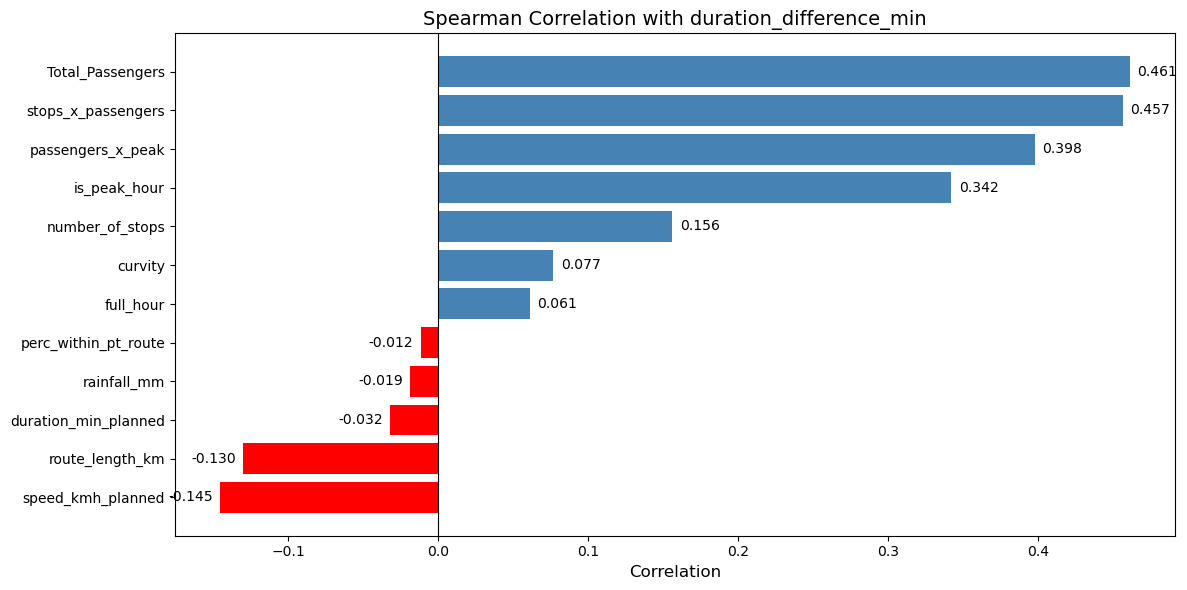

In [34]:
numerical_cols = ['full_hour', 'route_length_km', 'number_of_stops', 'rainfall_mm',
                  'Total_Passengers', 'curvity',
                  'duration_min_planned', 'speed_kmh_planned', 'perc_within_pt_route', 'is_peak_hour', 'passengers_x_peak', 'stops_x_passengers' ]

# חשב קורלציה עם המטרה
corr_with_target = df[numerical_cols].corrwith(df['duration_difference_min'], method='spearman').sort_values()

# צבע לפי חיובי/שלילי
colors = ['red' if x < 0 else 'steelblue' for x in corr_with_target]

plt.figure(figsize=(12, 6))
bars = plt.barh(corr_with_target.index, corr_with_target.values, color=colors)

# data labels
for bar, val in zip(bars, corr_with_target.values):
    plt.text(val + 0.005 if val >= 0 else val - 0.005,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Spearman Correlation with duration_difference_min', fontsize=14)
plt.xlabel('Correlation', fontsize=12)
plt.tight_layout()
plt.show()

## 1. Data types

In [35]:
from src.data_preparation import fix_data_types

df = fix_data_types(df)
print(df.dtypes)

date                         datetime64[ns]
day                                category
full_hour                             int64
line_num                              Int64
line_name                            object
route_id                              int64
route_mkt                             int64
direction                             int64
alternative                          object
agency_name                          object
route_type                           object
origin_city                          object
origin_station                       object
destination_city                     object
destination_station                  object
number_of_stops                       int64
route_length_km                     float64
departure_time_planned       datetime64[ns]
arrival_time_planned         datetime64[ns]
duration_min_planned                float64
duration_min_actual                 float64
duration_difference_min             float64
speed_kmh_planned               

### 1.1. Date & time

In [36]:
# Date
df['date'] = pd.to_datetime(df['date'])

# חלץ רק את השעה מהעמודות
df['departure_time_planned'] = pd.to_datetime(
    df['date'].dt.strftime('%Y-%m-%d') + ' ' + 
    pd.to_datetime(df['departure_time_planned'], format='mixed').dt.strftime('%H:%M:%S'),
    format='%Y-%m-%d %H:%M:%S'
)

df['arrival_time_planned'] = pd.to_datetime(
    df['date'].dt.strftime('%Y-%m-%d') + ' ' + 
    pd.to_datetime(df['arrival_time_planned'], format='mixed').dt.strftime('%H:%M:%S'),
    format='%Y-%m-%d %H:%M:%S'
)

print(df[['date', 'departure_time_planned', 'arrival_time_planned']].head())

        date departure_time_planned arrival_time_planned
0 2024-04-07    2024-04-07 12:30:00  2024-04-07 13:13:28
1 2024-04-10    2024-04-10 17:55:00  2024-04-10 19:00:09
2 2024-04-08    2024-04-08 23:20:00  2024-04-08 00:27:30
3 2024-04-09    2024-04-09 20:22:00  2024-04-09 21:20:59
4 2024-04-09    2024-04-09 21:35:00  2024-04-09 22:32:23


### 1.2. Numeric

In [37]:
# Hour
df = df.rename(columns={'hour_rounded': 'full_hour'})
print(df['full_hour'].dtype)

# Line_num
df['line_num'] = pd.to_numeric(df['line_num'], errors='coerce').astype('Int64')
print(df['line_num'].dtype)

int64
Int64


### 1.3. Categorial

In [38]:
# day - categorical with order
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)
print(df['day'].dtype)
str_cols = ['line_name', 'alternative', 'agency_name', 'origin_city', 
            'origin_station', 'destination_city', 'destination_station', 'route_type']
df[str_cols] = df[str_cols].astype(str)
df['route_type'] = df['route_type'].str.strip()

category


## 2. Missing values handling

### 2.2. Passengrs columns

In [39]:
for col in ['Total_Passengers']:
    df[col] = df.groupby(['route_id', 'direction', 'day', 'full_hour'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    print(f"{col} missing after fill: {df[col].isna().sum()}")


# שלב 2 - groupby פחות ספציפי
for col in ['Total_Passengers']:
    df[col] = df.groupby(['route_id', 'direction', 'day'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    print(f"{col} missing after step 2: {df[col].isna().sum()}")

# שלב 3 - אם עדיין חסר, לפי route_id בלבד
for col in ['Total_Passengers']:
    df[col] = df.groupby(['route_id'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    print(f"{col} missing after step 3: {df[col].isna().sum()}")

# שלב 4 - אם עדיין חסר, מלא עם חציון כללי
for col in ['Total_Passengers']:
    df[col] = df[col].fillna(df[col].median())
    print(f"{col} missing after step 4: {df[col].isna().sum()}")


missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)

missing_summary

C:\Users\Tamir\AppData\Local\Temp\ipykernel_29064\2633105291.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby(['route_id', 'direction', 'day', 'full_hour'])[col].transform(


Total_Passengers missing after fill: 691


C:\Users\Tamir\AppData\Local\Temp\ipykernel_29064\2633105291.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby(['route_id', 'direction', 'day'])[col].transform(


Total_Passengers missing after step 2: 57
Total_Passengers missing after step 3: 15
Total_Passengers missing after step 4: 0


,missing_count,missing_percent
stops_x_passengers,691,1.266821
Avg_Passengers_Per_Bus,691,1.266821
passengers_x_peak,691,1.266821
line_num,110,0.201665
length_in_buffer_m,109,0.199831
curvity,109,0.199831
circular_route,109,0.199831
perc_within_pt_route,109,0.199831
speed_kmh_actual,71,0.130165
duration_difference_min,71,0.130165


### 2.3 Duration columns

In [40]:
### Impute the remaining nulls of the duration and speed based on agency, line and hor average

df = impute_by_agency_line_hour(df, 'duration_min_actual')
df = impute_by_agency_line_hour(df, 'duration_difference_min')
df = impute_by_agency_line_hour(df, 'speed_kmh_actual')

duration_min_actual: filled 71 values using 'mean'
duration_difference_min: filled 71 values using 'mean'
speed_kmh_actual: filled 71 values using 'mean'


### 2.3. Spatial columns

In [41]:
cols = [
    "curvity",
    "route_length",
    "length_in_buffer_m"
]

for col in cols:
    df[col] = df[col].fillna(df[col].mean())

### 2.4. Missing values summary

In [42]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)

missing_summary

,missing_count,missing_percent
stops_x_passengers,691,1.266821
passengers_x_peak,691,1.266821
Avg_Passengers_Per_Bus,691,1.266821
line_num,110,0.201665
perc_within_pt_route,109,0.199831
circular_route,109,0.199831
perc_within_pt_route_peak,43,0.078833
is_peak_hour,0,0.000000
Total_Passengers,0,0.000000
duration_min_planned,0,0.000000


## 3. Outliers handling

#### 3.1.1. Very high speed

In [43]:
mask_high = df['speed_kmh_planned'] > 100
print(f"Rows with speed > 100: {mask_high.sum()}")

df.loc[mask_high, 'speed_kmh_planned'] = df.loc[mask_high, 'speed_kmh_planned'] / 1000

print(df['speed_kmh_planned'].describe())

Rows with speed > 100: 0
count    54546.000000
mean        25.299624
std         11.945443
min          0.000000
25%         17.900000
50%         20.100000
75%         28.279971
max         85.091445
Name: speed_kmh_planned, dtype: float64


#### 3.1.2. Very low speed

In [44]:
df[df['speed_kmh_planned'] < 0][['date', 'route_length', 'duration_min_planned', 'departure_time_planned', 'arrival_time_planned', 'speed_kmh_planned']].head(10)

## It looks like it happend because the ries ends in the next day

,date,route_length,duration_min_planned,departure_time_planned,arrival_time_planned,speed_kmh_planned


In [45]:
df['departure_time_planned'] = pd.to_datetime(df['departure_time_planned'].astype(str), format='mixed')
df['arrival_time_planned'] = pd.to_datetime(df['arrival_time_planned'].astype(str), format='mixed')

# זהה נסיעות שמסתיימות אחרי חצות
mask_midnight = df['arrival_time_planned'] < df['departure_time_planned']
print(f"Trips ending after midnight: {mask_midnight.sum()}")

# תקן את duration_min_planned
df.loc[mask_midnight, 'duration_min_planned'] = (
    (df.loc[mask_midnight, 'arrival_time_planned'] + pd.Timedelta(days=1)) - 
    df.loc[mask_midnight, 'departure_time_planned']
).dt.total_seconds() / 60

# תקן את speed_kmh_planned
df.loc[mask_midnight, 'speed_kmh_planned'] = (
    (df.loc[mask_midnight, 'route_length'] / 1000) / 
    (df.loc[mask_midnight, 'duration_min_planned'] / 60)
)

print(df[mask_midnight][['departure_time_planned', 'arrival_time_planned', 
                          'duration_min_planned', 'speed_kmh_planned']].head())

Trips ending after midnight: 893
    departure_time_planned arrival_time_planned  duration_min_planned  \
2      2024-04-08 23:20:00  2024-04-08 00:27:30             67.500000   
52     2024-04-08 23:00:00  2024-04-08 00:36:46             96.766667   
79     2024-04-13 23:15:00  2024-04-13 00:29:53             74.883333   
83     2024-04-11 21:50:00  2024-04-11 00:01:41            131.683333   
113    2024-04-09 23:20:00  2024-04-09 00:16:00             56.000000   

     speed_kmh_planned  
2            23.857395  
52           34.751975  
79           45.352840  
83           53.134908  
113          18.042546  


In [46]:
df[df['speed_kmh_actual'] > 500][['route_length', 'duration_min_planned', 'departure_time_planned', 'arrival_time_planned', 'speed_kmh_planned', 'duration_min_actual', 'speed_kmh_actual']].head(10)

,route_length,duration_min_planned,departure_time_planned,arrival_time_planned,speed_kmh_planned,duration_min_actual,speed_kmh_actual
814,116130.759773,121.0,2024-04-10 10:00:00,2024-04-10 12:00:59,52.2,7.0,902.3
1214,33800.641562,59.0,2024-04-13 22:30:00,2024-04-13 23:29:29,32.2,1.0,1898.2
1724,19044.266329,60.0,2024-04-10 05:10:00,2024-04-10 06:10:11,16.9,1.0,1015.9
1880,20747.820365,60.0,2024-04-08 06:35:00,2024-04-08 07:34:59,19.1,1.0,1146.1
2204,351687.668373,248.0,2024-04-12 05:00:00,2024-04-12 09:07:59,77.5,25.0,768.3
2351,19856.178922,60.0,2024-04-08 05:43:00,2024-04-08 06:42:36,18.2,1.0,1090.1
2364,80511.581814,57.0,2024-04-13 22:30:00,2024-04-13 23:26:59,79.8,4.0,1137.5
2652,16892.833479,51.0,2024-04-08 07:30:00,2024-04-08 08:20:59,18.1,1.0,922.1
2827,25001.422501,55.0,2024-04-08 09:47:00,2024-04-08 10:41:59,24.3,1.0,1337.6
2939,42338.016253,80.0,2024-04-08 21:30:00,2024-04-08 22:49:59,28.5,3.0,761.3


In [47]:
before = len(df)

df = df[(df['duration_difference_min'] >= -120) & 
        (df['duration_difference_min'] <= 120)]

after = len(df)
print(f"Rows removed: {before - after:,} ({(before-after)/before*100:.2f}%)")
print(f"Rows remaining: {after:,}")
print(df['duration_difference_min'].describe().round(2))

Rows removed: 231 (0.42%)
Rows remaining: 54,315
count    54315.00
mean        16.32
std         18.27
min       -120.00
25%          8.00
50%         17.02
75%         27.00
max        118.00
Name: duration_difference_min, dtype: float64


#### 3.1.3. Check speed box plot

## 4. Feature selection

In [48]:
df = df.drop(columns=['route_dir_alt_day_hr', 'line_num_agency_alter_dir', 'SIRI_id', 'gtfs_ride_id', 'gtfs_route_id' ], errors='ignore')
df.dtypes

date                         datetime64[ns]
day                                category
full_hour                             int64
line_num                              Int64
line_name                            object
route_id                              int64
route_mkt                             int64
direction                             int64
alternative                          object
agency_name                          object
route_type                           object
origin_city                          object
origin_station                       object
destination_city                     object
destination_station                  object
number_of_stops                       int64
route_length_km                     float64
departure_time_planned       datetime64[ns]
arrival_time_planned         datetime64[ns]
duration_min_planned                float64
duration_min_actual                 float64
duration_difference_min             float64
speed_kmh_planned               

## 5. Categorical Data Handling

In [49]:
from src.data_preparation import encode_categorical_columns

df = encode_categorical_columns(df)

New columns added: day_encoded, ['alternative_#', 'alternative_0', 'alternative_1', 'alternative_2', 'alternative_21', 'alternative_26', 'alternative_3', 'alternative_4', 'alternative_48', 'alternative_49', 'alternative_5', 'alternative_50', 'alternative_6', 'alternative_8', 'alternative_9', 'alternative_א', 'alternative_ב', 'alternative_ד', 'alternative_ז', 'alternative_ח', 'alternative_ט', 'alternative_ך', 'alternative_כ', 'alternative_ם', 'alternative_ן', 'alternative_נ', 'alternative_פ', 'alternative_ק']
Target encoded: ['agency_name_encoded', 'origin_city_encoded', 'destination_city_encoded', 'origin_station_encoded', 'destination_station_encoded']


### 5.1. Ordinal

In [50]:
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

day_mapping = {day: i for i, day in enumerate(day_order)}
df['day_encoded'] = df['day'].map(day_mapping)

print(df[['day', 'day_encoded']].drop_duplicates().sort_values('day_encoded'))

          day day_encoded
0      Sunday           0
2      Monday           1
3     Tuesday           2
1   Wednesday           3
8    Thursday           4
7      Friday           5
38   Saturday           6


### 5.2. Get dummies

In [51]:
alternative_dummies = pd.get_dummies(df['alternative'], prefix='alternative')

df = pd.concat([df, alternative_dummies], axis=1)

print(f"New columns added: {alternative_dummies.columns.tolist()}")
print(df[['alternative'] + alternative_dummies.columns.tolist()].drop_duplicates().sort_values('alternative'))

New columns added: ['alternative_#', 'alternative_0', 'alternative_1', 'alternative_2', 'alternative_21', 'alternative_26', 'alternative_3', 'alternative_4', 'alternative_48', 'alternative_49', 'alternative_5', 'alternative_50', 'alternative_6', 'alternative_8', 'alternative_9', 'alternative_א', 'alternative_ב', 'alternative_ד', 'alternative_ז', 'alternative_ח', 'alternative_ט', 'alternative_ך', 'alternative_כ', 'alternative_ם', 'alternative_ן', 'alternative_נ', 'alternative_פ', 'alternative_ק']
      alternative  alternative_#  alternative_#  alternative_0  alternative_0  \
2               #           True           True          False          False   
0               0          False          False           True           True   
7               1          False          False          False          False   
82              2          False          False          False          False   
48541          21          False          False          False          False   
10684        

### 5.3. Target

In [52]:


target_cols = ['agency_name', 'origin_city', 'destination_city', 
               'origin_station', 'destination_station']

te = TargetEncoder()
df[[f'{col}_encoded' for col in target_cols]] = te.fit_transform(
    df[target_cols], 
    df['duration_difference_min']
)

print("New encoded columns:")
for col in target_cols:
    print(f"\n{col} vs {col}_encoded:")
    print(df[[col, f'{col}_encoded']].drop_duplicates().head(5).round(2))

New encoded columns:

agency_name vs agency_name_encoded:
  agency_name  agency_name_encoded
0         Dan                18.69
2       Egged                15.21
4  Metropolin                14.22
7       Tnufa                11.10
8       Kavim                13.46

origin_city vs origin_city_encoded:
     origin_city  origin_city_encoded
0    תל אביב יפו                16.86
6   יהוד מונוסון                16.43
8    ראשון לציון                14.61
9            לוד                12.72
11         בת ים                19.71

destination_city vs destination_city_encoded:
  destination_city  destination_city_encoded
0      תל אביב יפו                     15.63
1            חולון                     19.51
2           רחובות                     14.24
4            רעננה                     13.47
5          בני ברק                     25.37

origin_station vs origin_station_encoded:
                   origin_station  origin_station_encoded
0                    מסוף הטייסים                

## 6. Feature engineering

In [53]:
### Add circular route flag
from src.data_preparation import add_circular_route_flag
df = add_circular_route_flag(
    df,
    routes_linestring_path="../data/interim_data/routes_linestrings.csv",
    route_id_col="route_id"
)

In [54]:
df['urban'] = df['route_length'] <=25000

In [55]:
### Calculating the percetnage of the distance inside the public transport path from the entire route length
df['perc_within_pt_route'] = round(df['length_in_buffer_m']/df['route_length']*100,2)

In [56]:
peak_hours = [7, 8, 9, 14, 15, 16, 17]

df['perc_within_pt_route_peak'] = df.apply(
    lambda row: row['perc_within_pt_route'] if row['full_hour'] in peak_hours else 0,
    axis=1
)

df['is_peak_hour'] = df['full_hour'].isin(peak_hours).astype(int)

In [57]:
df.to_csv(r'../data/model_datasets/train_df_to_ml.csv',index=False,encoding='utf-8-sig')


## 7. Manipulation pipelines